To construct our global partition of ENSO teleconnections, we examine whether reanalysis grid cells
exhibit surface temperatures that are positively correlated with NINO3 on a monthly basis (with a two month lag) for at least three months out of the year


In [ ]:
#Nino_my = El Nino Index in month m, year y
# T(x, m, y) = surface temperature at location x, month m and year y
#  ρ(x, m, L) be the correlation coefficient (over all years y ∈ Y ) of NINO(m, y) and T(x, m + L, y)

In [27]:
import os
from dotenv import load_dotenv
import xarray as xr

from scipy import stats

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import analysis_utils
import plotting_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

import diagnostic_utils

importlib.reload(diagnostic_utils)

<module 'diagnostic_utils' from '/home/emily_zuetell/projects/poreallas/analysis/diagnostic_utils.py'>

In [ ]:
# Projection Effects
load_dotenv()
# Baseline period for Impact
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
effect = xr.open_datatree(EFFECTS_URI, consolidated=False)
BASELINE_PERIOD = analysis_utils.get_baseline_period(effect, years=30)
# Define Forecast Months
FC_MONTHS = [9, 10, 11, 12, 1, 2]
FC_PERIOD = slice("2026-09-01", "2027-02-28")

config = analysis_utils.ImpactConfig( version = "v260929",
                                     baseline_period=BASELINE_PERIOD, 
                                     polygons_path= os.environ["POREALLAS_REGIONS_POLYGONS_URI"],
                                     socioeconomics_path= os.environ["POREALLAS_SOCIOECONOMICS_URI"],
                                     rate=True, 
                                     months = FC_MONTHS,
                                     hotonly = "net", 
                                     age_weight= False,
                                     dims = ['number', 'sample'])

In [ ]:
def nino34_index(ds, var="tas", clim=("1991-01-01", "2020-12-31"), oni=True):
    ## Based on: https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni
    # Compute NINO3.4 Index from ERA5 reanalysis
    sst = ds[var]
    # Make sure lat is ascending
    sst = sst.sortby("lat")
    # Set NINO3.4 Bounding Box
    box = sst.sel(lat=slice(-5, 5), lon=slice(-170, -120))
    # Daily -> Monthly TAS
    monthly = box.resample(time="1MS").mean()
    # Compute area averaged total SST from Niño X region
    weights = np.cos(np.deg2rad(monthly.lat))
    area_mean = monthly.weighted(weights).mean(("lat", "lon"))

    # subtract climatology from area averaged total SST time series to obtain anomalies
    climatology = area_mean.sel(time=slice(*clim)).groupby("time.month").mean()
    anom = area_mean.groupby("time.month") - climatology

    if oni:
        #Smooth the anomalies with a 3-month running mean
            anom = anom.rolling(time=3, center=True).mean()
    # Normalize
    std = anom.sel(time=slice(*clim)).std("time")
    return (anom / std).drop_vars("month")

In [ ]:
def lagged_corr_by_month(da, nino, lags):
    # Compute Monthly lagged correlation
    def corr_one_lag(lag):
        # Align xarrays
        pair = xr.Dataset({"x": da, "y": nino.shift(time=lag)})
        # Compute Corr
        return pair.groupby("time.month").map(
            lambda g: xr.corr(g.x, g.y, dim="time")
        )

    return xr.concat(
        [corr_one_lag(lag) for lag in lags],
        dim=xr.DataArray(list(lags), dims="lag", name="lag"),
    )

In [ ]:
## Build NINO3.4 Index from ERA5 (Note Sol uses NINO3, but https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni says 3.4 is better )
_ds = xr.open_dataset(
    "/home/emily_zuetell/projects/poreallas/data/v20260903_parsed_era5.zarr",
    engine="zarr",
    chunks={},
)
# Monthly TAS
monthly = _ds.resample(time="1MS").mean()

# TAS by Impact Region
era5_ir = isku_utils.grid_to_ir(monthly, savefile=None)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [4]:
nino34 = nino34_index(_ds)

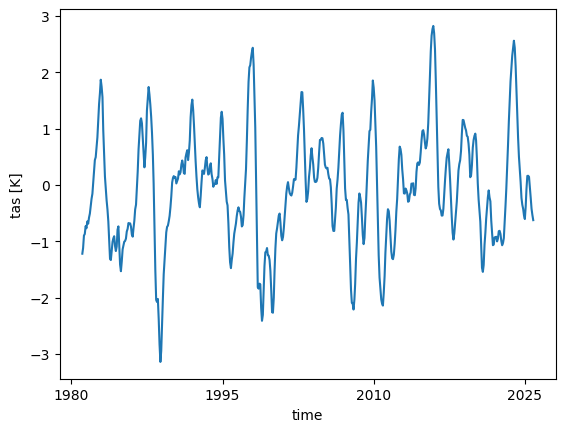

In [5]:
nino34.plot()

In [ ]:
def corr_pvalue(r, n):
    # Student's t-distribution with n − 2 degrees of freedom
    t = r * np.sqrt((n - 2) / (1 - r**2))
    # Two-sided survival function
    return xr.apply_ufunc(
        lambda t, df: 2 * stats.t.sf(np.abs(t), df),
        t, n - 2,
        dask="parallelized",
        output_dtypes=[float],
    )

In [ ]:
# Lag = 2 (Based on Hsiang et al. 2011)
lags = [2]
# Compute correlation
r = lagged_corr_by_month(era5_ir['tas'], nino34, lags)
# n = valid year pairs (for statistical significance)
n = xr.concat(
    [
        (era5_ir['tas'].notnull() & nino34.shift(time=lag).notnull()).groupby("time.month").sum("time")
        for lag in lags
    ],
    dim=xr.DataArray(list(lags), dims="lag", name="lag"),
)
# p-value
p = corr_pvalue(r, n)
# Binary signficance threshold (alpha = 0.1)
rho_tilde = ((p <= 0.1) & (r > 0)).astype(int)

In [33]:
_polygons_teleconnection = analysis_utils.xarray_to_gpd(
    rho_tilde.sum(dim = 'month'), config.polygons
)

<Axes: >

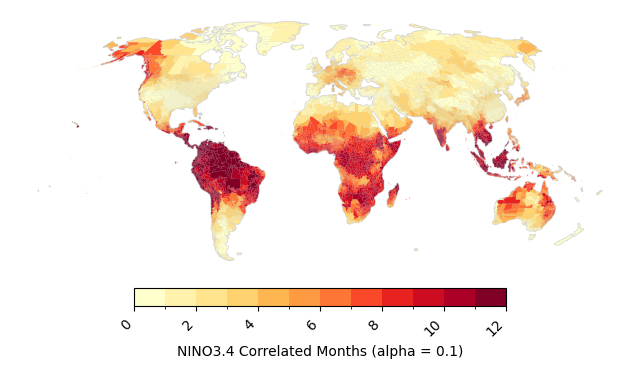

In [36]:
plotting_utils.plot_single(
    _polygons_teleconnection,
    col="value",
    cm="YlOrRd",
    n_colors=13,
    vmin=0,
    vmax=12,
    sup_title="",
    cbar_label="NINO3.4 Correlated Months (alpha = 0.1)",
    cbar_location="bottom",
)